In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from src.utils.preprocessing import load_breast_cancer_data
from src.utils.bias_variance_helper import (
    run_bias_variance_experiment,
    plot_bias_variance,
)

In [3]:
RANDOM_STATE = 42
TEST_SIZE = 0.30
B = 100
N_ESTIMATORS = 100

In [4]:
X_bc, y_bc, _ = load_breast_cancer_data(
    optimize_memory=False,
    verbose=False,
)

X = X_bc.to_numpy(dtype=np.float64)
y = y_bc.to_numpy().ravel().astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(pd.Series(y).value_counts(normalize=True).sort_index())

X shape: (569, 30)
y shape: (569,)
Class distribution:
0    0.372583
1    0.627417
Name: proportion, dtype: float64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train samples:", len(y_train))
print("Test samples:", len(y_test))

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Train samples: 398
Test samples: 171

Train class distribution:
0    0.371859
1    0.628141
Name: proportion, dtype: float64

Test class distribution:
0    0.374269
1    0.625731
Name: proportion, dtype: float64


In [7]:
bias_variance_results = run_bias_variance_experiment(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_bootstrap=B,
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    rf_n_jobs=-1,
)

In [8]:
display(
    bias_variance_results.style.format(
        {
            "bias_squared": "{:.6f}",
            "variance": "{:.6f}",
            "total_error": "{:.6f}",
            "bias_plus_variance": "{:.6f}",
            "difference": "{:.10f}",
            "mean_accuracy": "{:.4f}",
            "ensemble_accuracy": "{:.4f}",
        }
    )
)

,model,bias_squared,variance,total_error,bias_plus_variance,difference,mean_accuracy,ensemble_accuracy
0,AdaBoost,0.026062,0.014658,0.040720,0.040720,0.0000000000,0.9556,0.9649
1,Random Forest,0.036277,0.002404,0.038681,0.038681,0.0000000000,0.9415,0.9474


In [9]:
check_df = bias_variance_results[
    [
        "model",
        "bias_squared",
        "variance",
        "total_error",
        "bias_plus_variance",
        "difference",
    ]
].copy()

display(
    check_df.style.format(
        {
            "bias_squared": "{:.8f}",
            "variance": "{:.8f}",
            "total_error": "{:.8f}",
            "bias_plus_variance": "{:.8f}",
            "difference": "{:.12f}",
        }
    )
)

,model,bias_squared,variance,total_error,bias_plus_variance,difference
0,AdaBoost,0.02606240,0.01465807,0.04072047,0.04072047,0.000000000000
1,Random Forest,0.03627721,0.00240366,0.03868087,0.03868087,0.000000000000


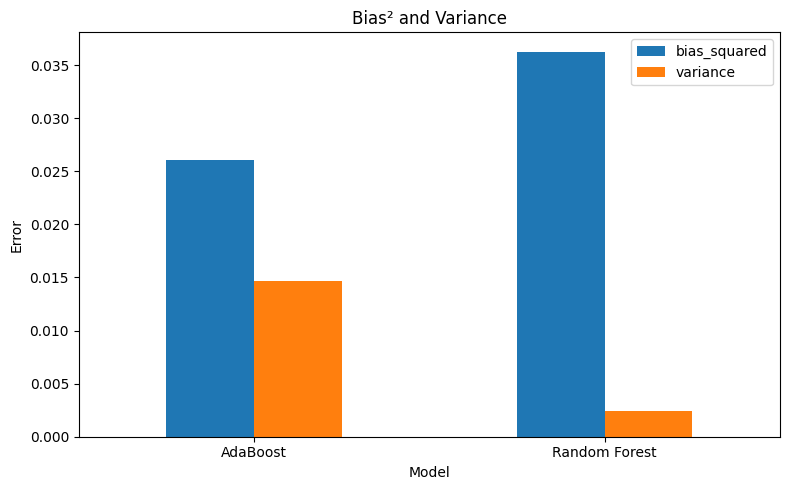

In [10]:
plot_bias_variance(
    bias_variance_results
)

In [11]:
for _, row in bias_variance_results.iterrows():
    print(f"\n{row['model']}")
    print(f"Bias²: {row['bias_squared']:.6f}")
    print(f"Variance: {row['variance']:.6f}")
    print(f"Total error: {row['total_error']:.6f}")
    print(
        "Bias² + Variance: "
        f"{row['bias_plus_variance']:.6f}"
    )
    print(
        "Decomposition difference: "
        f"{row['difference']:.12f}"
    )
    print(
        "Mean individual accuracy: "
        f"{row['mean_accuracy']:.4f}"
    )
    print(
        "Aggregated accuracy: "
        f"{row['ensemble_accuracy']:.4f}"
    )


AdaBoost
Bias²: 0.026062
Variance: 0.014658
Total error: 0.040720
Bias² + Variance: 0.040720
Decomposition difference: 0.000000000000
Mean individual accuracy: 0.9556
Aggregated accuracy: 0.9649

Random Forest
Bias²: 0.036277
Variance: 0.002404
Total error: 0.038681
Bias² + Variance: 0.038681
Decomposition difference: 0.000000000000
Mean individual accuracy: 0.9415
Aggregated accuracy: 0.9474


## Final Conclusion

The results demonstrate the main difference between bagging and boosting.

Random Forest, which uses bagging, achieved much lower variance:

* AdaBoost variance: 0.014658
* Random Forest variance: 0.002404

This shows that bagging makes the model more stable by averaging predictions from multiple bootstrap-trained trees.

AdaBoost, which uses boosting, achieved lower bias²:

* AdaBoost bias²: 0.026062
* Random Forest bias²: 0.036277

This shows that boosting reduces bias by sequentially focusing on previously misclassified samples.

Overall, the experiment confirms that bagging mainly reduces variance, while boosting mainly reduces bias.
